Biometrich Technologies and Behavioural Security
# **<center>Tutorial 7 - Behavioral biometric: EEG signal </center>**
### <center> Part 2 </center>

An interesting time series classification problem is predicting whether a subject’s eyes are open or closed based only on their brain wave data (EEG). In this tutorial, you will discover the problem of predicting whether eyes are open or closed based on brain waves

##Step 1: Download Dataset

The file "EEG Eye State.txt" contains instances of EEG measurements where the output is whether eye was open or not.


Specifically, the electroencephalography (EEG) recording was made of a single person for 117 seconds (just under two minutes) while the subject opened and closed his eyes, which was recorded via a video camera. The open/closed state was then recorded against each time step in the EEG trace manually.

The EEG was recorded using a <a href="https://www.emotiv.com/">Emotiv EEG Neuroheadset</a>, resulting in 14 traces.

All data is from one continuous EEG measurement with the Emotiv EEG Neuroheadset. The duration of the measurement was 117 seconds. The eye state was detected via a camera during the EEG measurement and added later manually to the file after analyzing the video frames.

*   0 indicates the eye-open state;
*   1 indicates the eye-closed;


A total of 14,980 observations (rows) were made over the 117 seconds, meaning that there were about 128 observations per second.

The corpus consists of 14,977 instances with 15 attributes each (14 attributes representing the values of the electrodes and the eye state, the last one represents the label). The instances are stored in the corpus in chronological order to be able to analyze temporal dependencies. 8,255 (55.12%) instances of the corpus correspond to the eye open and 6,722 (44.88%) instances to the eye closed state.

The 14 features correspond to 14 EEG measurements from the headset, labeled AF3, F7, F3, FC5, T7, P, O1, O2, P8, T8, FC6, F4, F8, AF4.

In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
from pandas import read_csv
from numpy import mean
from numpy import std
from numpy import delete
from numpy import savetxt
from matplotlib import pyplot

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id': '1R9SnVSeJoSCwyNldRlxMneB6_g3DoD6Y'})
downloaded.GetContentFile('EEG Eye State.txt')

###Step 1.1 Signals Plots

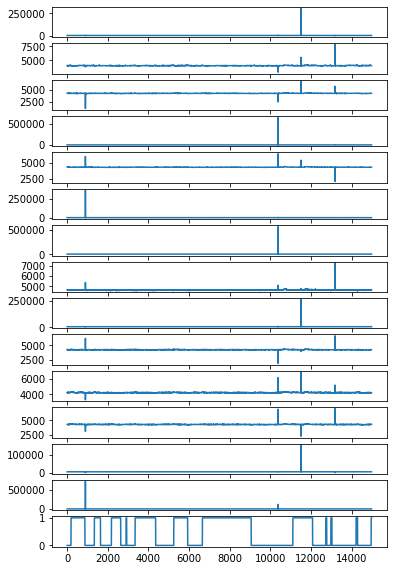

In [ ]:
# load the dataset
data = read_csv('/content/EEG Eye State.txt', header=None)
# retrieve data as numpy array
values = data.values
# create a subplot for each time series
pyplot.figure()
for i in range(values.shape[1]):
	pyplot.subplot(values.shape[1], 1, i+1)
	pyplot.plot(values[:, i])

pyplot.subplots_adjust(top=2)
pyplot.show()

### Step 1.2 Delete outliers

In [ ]:
# step over each EEG column
for i in range(values.shape[1] - 1):
	# calculate column mean and standard deviation
	data_mean, data_std = mean(values[:,i]), std(values[:,i])
	# define outlier bounds
	cut_off = data_std * 4
	lower, upper = data_mean - cut_off, data_mean + cut_off
	# remove too small
	too_small = [j for j in range(values.shape[0]) if values[j,i] < lower]
	values = delete(values, too_small, 0)
	print('>deleted %d rows' % len(too_small))
	# remove too large
	too_large = [j for j in range(values.shape[0]) if values[j,i] > upper]
	values = delete(values, too_large, 0)
	print('>deleted %d rows' % len(too_large))
# save the results to a new file
savetxt('EEG_Eye_State_no_outliers.csv', values, delimiter=',')

>deleted 0 rows
>deleted 1 rows
>deleted 2 rows
>deleted 1 rows
>deleted 0 rows
>deleted 142 rows
>deleted 0 rows
>deleted 48 rows
>deleted 0 rows
>deleted 153 rows
>deleted 0 rows
>deleted 43 rows
>deleted 0 rows
>deleted 0 rows
>deleted 0 rows
>deleted 15 rows
>deleted 0 rows
>deleted 5 rows
>deleted 10 rows
>deleted 0 rows
>deleted 21 rows
>deleted 53 rows
>deleted 0 rows
>deleted 12 rows
>deleted 58 rows
>deleted 53 rows
>deleted 0 rows
>deleted 59 rows


###Step 1.3 Signals Plots with no outliers

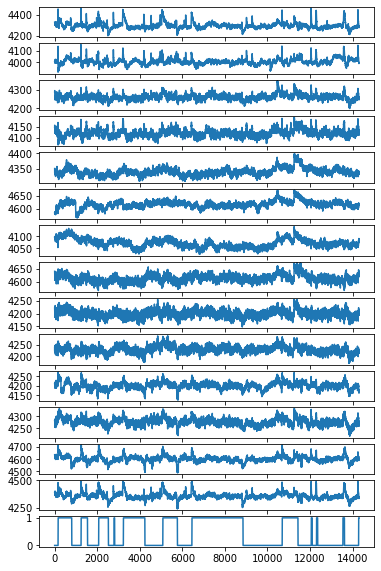

In [ ]:
# visualize dataset without outliers
from pandas import read_csv
from matplotlib import pyplot
# load the dataset
data = read_csv('EEG_Eye_State_no_outliers.csv', header=None)
# retrieve data as numpy array
values = data.values
# create a subplot for each time series
pyplot.figure()
for i in range(values.shape[1]):
	pyplot.subplot(values.shape[1], 1, i+1)
	pyplot.plot(values[:, i])

pyplot.subplots_adjust(top=2)
pyplot.show()

## Step 2: Model definition

### Step 2.1 Split dataset into train and test set

In [ ]:
from sklearn.model_selection import train_test_split
# split data into inputs and outputs
X, y = values[:, :-1], values[:, -1]
# split the dataset
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=1)
#

### Step 2.2 Train on a KNN

Define a KNN model with 3 neighbours, train it and test it (you can find it in Scikit-learn library).

In [ ]:
#Example KNN for predicting eye state
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

# fit model on train set
model.fit(trainX, trainy)
# forecast test set
predictions = model.predict(testX)
# evaluate predictions
acc='KNN: Total Accuracy: %.2f %%' % (accuracy_score(testy, predictions)*100)
print(acc)

KNN: Total Accuracy: 97.00 %


### Step 2.3 Train on a Neural Network

We can now repeat the experiment by training a neural network.


Build your own NN, with at least 3 hidden layers. Feel free to try different combination of epochs/output numbers/etc.

Normalization of data is required before using it on Neural Networks

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# split data into inputs and outputs
x, y = values[:, :-1], values[:, -1]

scaler.fit(x)
x_new = scaler.transform(x)

data_mean = x.mean()
data_std = x.std()
x = (x - data_mean)/data_std

In [ ]:
# split the normalised dataset
trainX, testX, trainy, testy = train_test_split(x, y, test_size=0.1, shuffle=True, random_state=1)

#### Creating Model

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

model2 = Sequential()
model2.add(Dense(1000, activation = 'relu', input_shape = (x.shape[1], )))
model2.add(Dropout(0.2))
model2.add(Dense(1000, activation = 'relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1000, activation = 'relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation = 'sigmoid'))
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1000)              15000     
                                                                 
 dropout (Dropout)           (None, 1000)              0         
                                                                 
 dense_1 (Dense)             (None, 1000)              1001000   
                                                                 
 dropout_1 (Dropout)         (None, 1000)              0         
                                                                 
 dense_2 (Dense)             (None, 1000)              1001000   
                                                                 
 dropout_2 (Dropout)         (None, 1000)              0         
                                                                 
 dense_3 (Dense)             (None, 1)                 1

In [ ]:
model2.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1000)              15000     
                                                                 
 dropout (Dropout)           (None, 1000)              0         
                                                                 
 dense_1 (Dense)             (None, 1000)              1001000   
                                                                 
 dropout_1 (Dropout)         (None, 1000)              0         
                                                                 
 dense_2 (Dense)             (None, 1000)              1001000   
                                                                 
 dropout_2 (Dropout)         (None, 1000)              0         
                                                                 
 dense_3 (Dense)             (None, 1)                 1

In [ ]:
from keras.callbacks import ModelCheckpoint

checkpointer = ModelCheckpoint(filepath = 'MLP_new.weights.best.hdf5', verbose = 1, save_best_only = True)
hist1 = model2.fit(trainX, trainy, epochs = 200, batch_size=512, validation_split = 0.1, callbacks = [checkpointer], verbose = 2, shuffle = False )

Epoch 1/200

Epoch 1: val_loss improved from inf to 0.68234, saving model to MLP_new.weights.best.hdf5
23/23 - 4s - loss: 0.6924 - accuracy: 0.5387 - val_loss: 0.6823 - val_accuracy: 0.5520 - 4s/epoch - 178ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.68234 to 0.65990, saving model to MLP_new.weights.best.hdf5
23/23 - 0s - loss: 0.6685 - accuracy: 0.5833 - val_loss: 0.6599 - val_accuracy: 0.6149 - 353ms/epoch - 15ms/step
Epoch 3/200

Epoch 3: val_loss improved from 0.65990 to 0.64790, saving model to MLP_new.weights.best.hdf5
23/23 - 0s - loss: 0.6534 - accuracy: 0.6035 - val_loss: 0.6479 - val_accuracy: 0.6250 - 359ms/epoch - 16ms/step
Epoch 4/200

Epoch 4: val_loss improved from 0.64790 to 0.63567, saving model to MLP_new.weights.best.hdf5
23/23 - 0s - loss: 0.6428 - accuracy: 0.6176 - val_loss: 0.6357 - val_accuracy: 0.6359 - 347ms/epoch - 15ms/step
Epoch 5/200

Epoch 5: val_loss improved from 0.63567 to 0.62338, saving model to MLP_new.weights.best.hdf5
23/23 - 0s - loss: 

In [ ]:
score = model2.evaluate(testX, testy, verbose=1)
print("Accuracy: ", score[1])

45/45 [==============================] - 0s 3ms/step - loss: 0.1037 - accuracy: 0.9644
Accuracy:  0.9643605947494507
